# Data Preparation & Feature Engineering for Time Series

Module 2 of the time-series notes, worked end to end on one product from the French bakery dataset.

Each section gives **the formula**, **the code**, and **what it does to this series**, with the numbers computed rather than asserted.

**Series:** `TRADITIONAL BAGUETTE` -- 637 daily observations, 2021-01-02 to 2022-09-30. The exploratory analysis lives in [EDA.ipynb](EDA.ipynb); the findings we build on here are: a strong 7-day season, an annual season peaking in August, variance that scales with the level, and 37 zero-sale days that are **shop closures, not demand**.

---

### The one rule that matters: no leakage

Every feature below must be computable **at prediction time** from information available **strictly before** the target timestamp. Two failure modes account for almost all leakage bugs in time series:

1. **Forgetting to shift.** `y.rolling(7).mean()` at time $t$ includes $y_t$ itself -- the value you are trying to predict. It must be `y.shift(1).rolling(7).mean()`.
2. **Fitting on the full series.** Box-Cox $\lambda$, imputation values, outlier thresholds and scalers must all be estimated on the **training split only**, then applied to the test split.

Sections are ordered to match the syllabus. The order you would actually *execute* them in is different, and is assembled in section 10.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.special import inv_boxcox
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

In [2]:
PRODUCT = "TRADITIONAL BAGUETTE"

raw = pd.read_csv("../data/daily_sales_french_bakery.csv", parse_dates=["ds"])
s = raw[raw["unique_id"] == PRODUCT].sort_values("ds").set_index("ds")

y = s["y"].asfreq("D")          # regular daily index
HORIZON = 7                     # we forecast one week ahead
SEASON  = 7                     # weekly season

print("observations :", len(y))
print("range        :", y.index.min().date(), "->", y.index.max().date())
print("zero days    :", int((y == 0).sum()), "(shop closures)")
y.head()

observations : 637
range        : 2021-01-02 -> 2022-09-30
zero days    : 37 (shop closures)


ds
2021-01-02    153.6
2021-01-03    205.2
2021-01-04    153.6
2021-01-05    118.8
2021-01-06      0.0
Freq: D, Name: y, dtype: float64

## 1. Lag features

The most direct way to give a flat (non-sequential) model access to history: past values become columns.

$$x^{(k)}_t = y_{t-k}$$

$k$ is the **lag**. In pandas this is `y.shift(k)` -- shifting *forward* so that row $t$ carries the value from $t-k$.

**Which lags?** Not arbitrary ones. Pick from the ACF/PACF (see EDA section 8-9) and from domain structure:

- $k = 1, 2, 3$ -- short-run persistence.
- $k = m, 2m, \dots$ -- the seasonal lags ($m = 7$ here: same weekday last week).
- $k = 364$ -- same weekday one year earlier ($364 = 52 \times 7$, which preserves weekday alignment; 365 does not).

**The horizon constraint.** To forecast $h$ steps ahead with a single direct model, at prediction time you only know values up to $T$. Predicting $y_{T+7}$ means **every lag must satisfy $k \geq h$** -- lag 1 relative to the target is a value you will not have. This is the single most common leakage bug in tabular time-series pipelines.

In [3]:
LAGS = [1, 2, 3, 7, 14, 21, 28, 364]

lag_df = pd.DataFrame({f"lag_{k}": y.shift(k) for k in LAGS})
lag_df.insert(0, "y", y)

print("correlation of each lag with y")
for k in LAGS:
    print(f"  lag {k:3d}: {y.corr(y.shift(k)):.3f}")

lag_df.head(10)

correlation of each lag with y
  lag   1: 0.777
  lag   2: 0.626
  lag   3: 0.534
  lag   7: 0.783
  lag  14: 0.656
  lag  21: 0.548
  lag  28: 0.455
  lag 364: 0.816


,y,lag_1,lag_2,lag_3,lag_7,lag_14,lag_21,lag_28,lag_364
ds,,,,,,,,,
2021-01-02,153.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-03,205.2,153.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-04,153.6,205.2,153.6,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,118.8,153.6,205.2,153.6,NaN,NaN,NaN,NaN,NaN
2021-01-06,0.0,118.8,153.6,205.2,NaN,NaN,NaN,NaN,NaN
2021-01-07,130.8,0.0,118.8,153.6,NaN,NaN,NaN,NaN,NaN
2021-01-08,93.6,130.8,0.0,118.8,NaN,NaN,NaN,NaN,NaN
2021-01-09,162.0,93.6,130.8,0.0,153.6,NaN,NaN,NaN,NaN
2021-01-10,168.0,162.0,93.6,130.8,205.2,NaN,NaN,NaN,NaN


**Observations**

- **Lag 364 is the strongest predictor of all (r = 0.816)** -- stronger than yesterday (0.777) or last week (0.783). The annual cycle dominates this series, and matching the weekday from a year ago captures both seasons at once.
- Lag 7 (0.783) edges out lag 1 (0.777): last week's same weekday is as informative as yesterday.
- Correlation decays smoothly through the seasonal lags -- 7: 0.783, 14: 0.656, 21: 0.548, 28: 0.455.
- The cost of lag 364 is **364 unusable rows** (57% of this series) plus the requirement of two years of history to compute it at all. On a 637-day series that trade is usually not worth it; on 5 years it is.

**Leakage check for our 7-day horizon:** `lag_1`, `lag_2` and `lag_3` are **unusable** for direct 7-step forecasting. Only $k \geq 7$ survives.

In [4]:
usable = [k for k in LAGS if k >= HORIZON]
dropped = [k for k in LAGS if k < HORIZON]

print(f"horizon = {HORIZON} days")
print("usable lags  :", usable)
print("dropped lags :", dropped, "-> not known at prediction time")

# NaNs introduced at the head of the series, one row per lag
print("\nrows lost to the largest lag:", lag_df[f"lag_{max(usable)}"].isna().sum())
print("complete rows if lag_364 is kept   :", int(lag_df.notna().all(axis=1).sum()))
print("complete rows if lag_364 is dropped:",
      int(lag_df.drop(columns=["lag_364"]).notna().all(axis=1).sum()))

horizon = 7 days
usable lags  : [7, 14, 21, 28, 364]
dropped lags : [1, 2, 3] -> not known at prediction time

rows lost to the largest lag: 364
complete rows if lag_364 is kept   : 273
complete rows if lag_364 is dropped: 609


## 2. Rolling statistics

A lag gives one noisy past value. A **rolling (moving) window** summarises the last $w$ observations, trading resolution for stability:

$$\mu_t = \frac{1}{w}\sum_{i=t-w}^{t-1} y_i
\qquad
\sigma_t = \sqrt{\frac{1}{w-1}\sum_{i=t-w}^{t-1}(y_i - \mu_t)^2}$$

with $\min_t$ and $\max_t$ defined over the same window. Each captures something different:

| Statistic | Captures |
|---|---|
| mean | local level -- a denoised "where are we now" |
| std | local volatility -- how uncertain is the level |
| min / max | the recent envelope; useful for capacity and for spotting regime shifts |
| max - min | range, a cheap robustness-free volatility proxy |

**Two choices that decide whether this works:**

- **`.shift(1)` first.** `y.rolling(7).mean()` includes $y_t$. That leaks the target into its own feature and inflates validation scores dramatically. For an $h$-step horizon, shift by $h$.
- **Window length.** Use multiples of the season ($7, 14, 28$) so each window holds whole weeks; otherwise the feature oscillates with whichever weekdays happen to fall inside it.

In [5]:
def rolling_features(series, windows=(7, 14, 28), shift=1):
    '''Leakage-safe rolling statistics: shift first, then roll.'''
    base = series.shift(shift)          # <-- the critical line
    out = {}
    for w in windows:
        out[f"roll{w}_mean"]  = base.rolling(w).mean()
        out[f"roll{w}_std"]   = base.rolling(w).std()
        out[f"roll{w}_min"]   = base.rolling(w).min()
        out[f"roll{w}_max"]   = base.rolling(w).max()
        out[f"roll{w}_range"] = out[f"roll{w}_max"] - out[f"roll{w}_min"]
    return pd.DataFrame(out)

roll_df = rolling_features(y, windows=(7, 28), shift=1)
roll_df.head(10)

,roll7_mean,roll7_std,roll7_min,roll7_max,roll7_range,roll28_mean,roll28_std,roll28_min,roll28_max,roll28_range
ds,,,,,,,,,,
2021-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-09,122.228571,64.157663,0.0,205.2,205.2,NaN,NaN,NaN,NaN,NaN
2021-01-10,123.428571,64.916298,0.0,205.2,205.2,NaN,NaN,NaN,NaN,NaN


In [6]:
# Why the shift matters, quantified
leaky = y.rolling(7).mean()          # includes y_t
safe  = y.shift(1).rolling(7).mean() # excludes y_t

print(f"corr(y, leaky roll7_mean) = {y.corr(leaky):.3f}   <- inflated, contains y_t")
print(f"corr(y, safe  roll7_mean) = {y.corr(safe):.3f}")

print("\ncorrelation of each safe rolling feature with y")
for c in roll_df.columns:
    print(f"  {c:15s}: {y.corr(roll_df[c]):.3f}")

corr(y, leaky roll7_mean) = 0.801   <- inflated, contains y_t
corr(y, safe  roll7_mean) = 0.763

correlation of each safe rolling feature with y
  roll7_mean     : 0.763
  roll7_std      : 0.265
  roll7_min      : 0.744
  roll7_max      : 0.730
  roll7_range    : 0.252
  roll28_mean    : 0.611
  roll28_std     : 0.254
  roll28_min     : 0.651
  roll28_max     : 0.523
  roll28_range   : 0.210


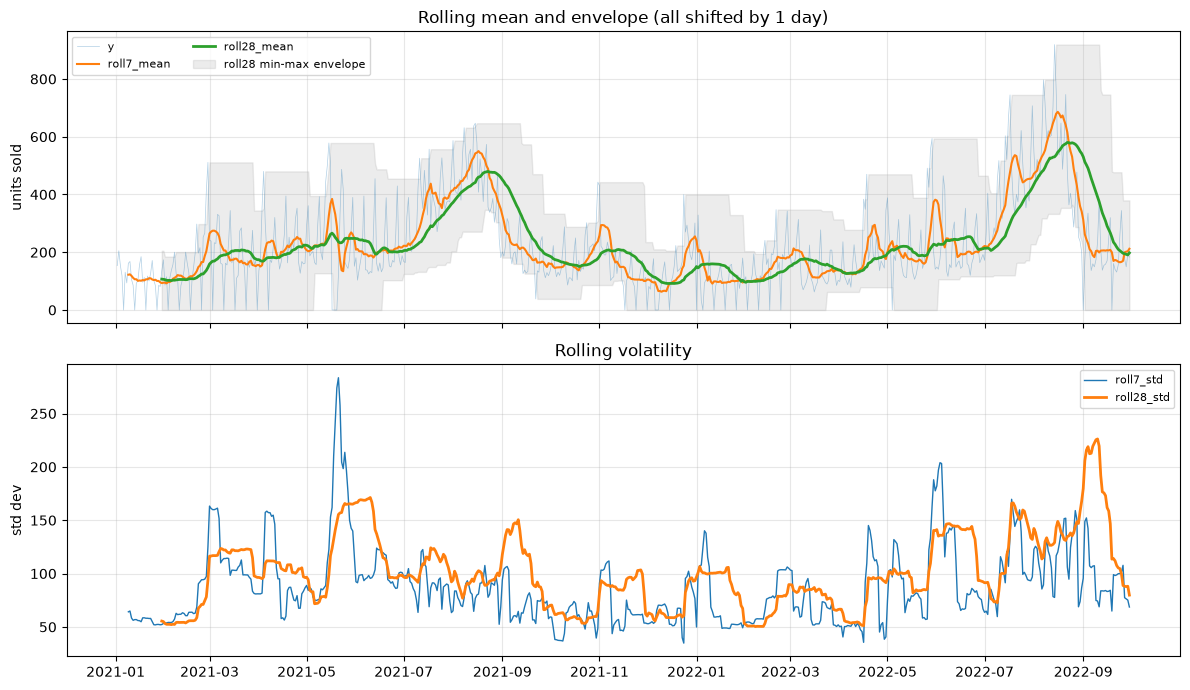

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.plot(y.index, y.values, lw=0.5, alpha=0.35, label="y")
ax1.plot(roll_df.index, roll_df["roll7_mean"], lw=1.5, label="roll7_mean")
ax1.plot(roll_df.index, roll_df["roll28_mean"], lw=2, label="roll28_mean")
ax1.fill_between(roll_df.index, roll_df["roll28_min"], roll_df["roll28_max"],
                 alpha=0.15, color="grey", label="roll28 min-max envelope")
ax1.set_ylabel("units sold")
ax1.set_title("Rolling mean and envelope (all shifted by 1 day)")
ax1.legend(ncol=2, fontsize=8)

ax2.plot(roll_df.index, roll_df["roll7_std"], lw=1, label="roll7_std")
ax2.plot(roll_df.index, roll_df["roll28_std"], lw=2, label="roll28_std")
ax2.set_ylabel("std dev")
ax2.set_title("Rolling volatility")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Observations**

- The leaky `roll7_mean` correlates **0.801** with `y` versus **0.763** for the shifted version. That gap is free accuracy in backtesting that evaporates in production -- and it is invisible unless you look for it.
- `roll28_mean` is the smoothest level signal and tracks the annual cycle; `roll7_mean` still carries weekday wobble because a 7-day window ending on a shifting weekday is not weekday-neutral.
- `roll7_std` and `roll28_std` both balloon in summer -- the level-dependent variance from the EDA. Passing volatility in as a feature lets a model condition on it instead of assuming it away.
- The min-max envelope widens dramatically in peak season; `roll28_range` is nearly useless in winter and highly informative in summer.

## 3. Expanding windows

An expanding window is a rolling window whose start is pinned to the beginning of the series -- it uses **all history to date**:

$$\mu^{\text{exp}}_t = \frac{1}{t-1}\sum_{i=1}^{t-1} y_i$$

| | Rolling | Expanding |
|---|---|---|
| memory | last $w$ points | everything so far |
| reacts to change | quickly | ever more slowly |
| variance of estimate | higher | falls as $t$ grows |
| stationarity needed | no | assumes a stable long-run mean |

**Where it is genuinely useful:** cumulative "to date" quantities (sales this year so far), a slow-moving baseline to compare the fast rolling mean against, and **expanding-window cross-validation**, where the training set grows with each fold.

**Where it misleads:** as a level estimate on a non-stationary series. By day 600 a single new observation moves the expanding mean by $1/600$ -- it has effectively stopped learning.

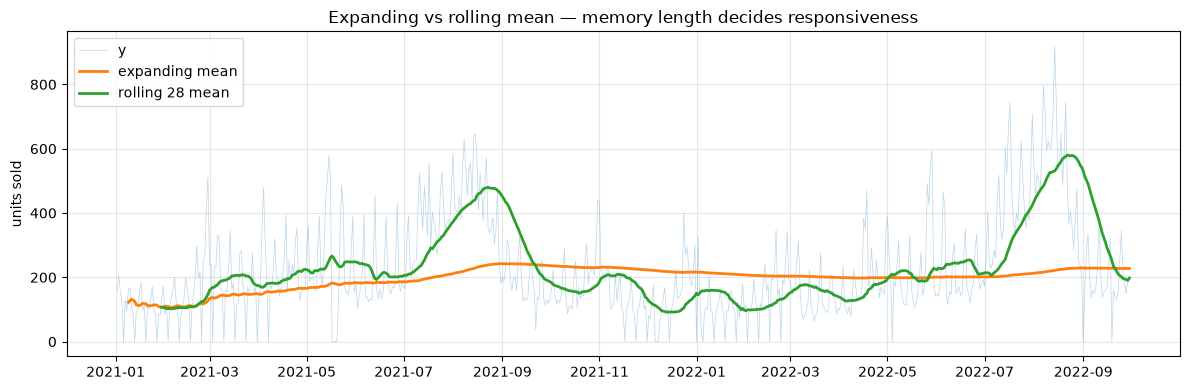

expanding mean: day 30 = 108.5, day 300 = 231.5, final = 227.3
expanding mean range: 106.1 -> 242.6
rolling 28  range   : 91.8 -> 580.2


In [8]:
base = y.shift(1)   # same leakage rule

exp_df = pd.DataFrame({
    "expanding_mean": base.expanding(min_periods=7).mean(),
    "expanding_std":  base.expanding(min_periods=7).std(),
    "expanding_max":  base.expanding(min_periods=7).max(),
    # cumulative sales within the current calendar year
    "ytd_sum": base.groupby(base.index.year).cumsum(),
})

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y.index, y.values, lw=0.5, alpha=0.3, label="y")
ax.plot(exp_df.index, exp_df["expanding_mean"], lw=2, label="expanding mean")
ax.plot(y.index, y.shift(1).rolling(28).mean(), lw=2, label="rolling 28 mean")
ax.set_title("Expanding vs rolling mean — memory length decides responsiveness")
ax.set_ylabel("units sold")
ax.legend()
plt.tight_layout()
plt.show()

em = exp_df["expanding_mean"].dropna()
print(f"expanding mean: day 30 = {em.iloc[29]:.1f}, day 300 = {em.iloc[299]:.1f}, final = {em.iloc[-1]:.1f}")
print(f"expanding mean range: {em.min():.1f} -> {em.max():.1f}")
print(f"rolling 28  range   : {y.shift(1).rolling(28).mean().min():.1f} -> "
      f"{y.shift(1).rolling(28).mean().max():.1f}")

**Observations**

- The expanding mean settles near the global average (~227) and then barely moves, while the rolling-28 mean swings from **92 to 580** tracking the seasons. On a strongly seasonal series the expanding mean is a **constant in disguise** -- it carries almost no usable signal.
- It does encode *position in the series*: early values are volatile (few observations), later ones are stable. A model can accidentally use it as a proxy for time index, which will not extrapolate.
- `ytd_sum` resets each January and is a legitimate business feature (progress against an annual target), not a level estimate.
- **Rule of thumb:** expanding statistics for cumulative business quantities and for CV design; rolling statistics for level and volatility features.

## 4. Date & time feature extraction

The timestamp is free information: unlike lags it is **known arbitrarily far into the future**, so these features are always available at any horizon and cost no rows.

**Calendar parts** -- `dayofweek`, `day`, `month`, `quarter`, `weekofyear`, `dayofyear`, `is_weekend`, `is_month_start/end`, holiday flags.

**The encoding problem.** Feeding `month` as the integer 1-12 tells a linear model that December (12) is eleven units away from January (1), when they are adjacent. Three fixes:

1. **One-hot** -- correct but costly ($m-1$ columns) and learns nothing about adjacency.
2. **Cyclical (sine/cosine)** -- map the cycle onto a circle:

$$x_{\sin} = \sin\!\left(\frac{2\pi t}{m}\right), \qquad x_{\cos} = \cos\!\left(\frac{2\pi t}{m}\right)$$

Two columns, and the Euclidean distance between adjacent periods is now equal everywhere -- including the wrap-around.

3. **Fourier terms** -- the same idea with $K$ harmonics, needed when the seasonal shape is not a simple sine:

$$\left\{\sin\!\left(\frac{2\pi k t}{m}\right),\ \cos\!\left(\frac{2\pi k t}{m}\right)\right\}_{k=1}^{K}$$

$K$ controls flexibility: $K=1$ is a pure wave, higher $K$ captures sharper peaks. For an annual cycle on daily data ($m = 365.25$), $K = 3$ to $6$ replaces 11 monthly dummies.

In [9]:
def calendar_features(index):
    '''Deterministic features derived from the timestamp alone.'''
    ix = pd.DatetimeIndex(index)
    out = pd.DataFrame(index=ix)

    out["dayofweek"]   = ix.dayofweek
    out["day"]         = ix.day
    out["month"]       = ix.month
    out["quarter"]     = ix.quarter
    out["weekofyear"]  = ix.isocalendar().week.astype(int).values
    out["dayofyear"]   = ix.dayofyear
    out["is_weekend"]  = (ix.dayofweek >= 5).astype(int)
    out["is_month_start"] = ix.is_month_start.astype(int)
    out["is_month_end"]   = ix.is_month_end.astype(int)

    # cyclical encoding of the weekly cycle
    out["dow_sin"] = np.sin(2 * np.pi * ix.dayofweek / 7)
    out["dow_cos"] = np.cos(2 * np.pi * ix.dayofweek / 7)

    # Fourier terms for the annual cycle
    for k in (1, 2, 3):
        out[f"year_sin{k}"] = np.sin(2 * np.pi * k * ix.dayofyear / 365.25)
        out[f"year_cos{k}"] = np.cos(2 * np.pi * k * ix.dayofyear / 365.25)

    return out

cal = calendar_features(y.index)
cal.head()

,dayofweek,day,month,quarter,weekofyear,dayofyear,is_weekend,is_month_start,is_month_end,dow_sin,dow_cos,year_sin1,year_cos1,year_sin2,year_cos2,year_sin3,year_cos3
ds,,,,,,,,,,,,,,,,,
2021-01-02,5,2,1,1,53,2,1,0,0,-0.974928,-0.222521,0.034398,0.999408,0.068755,0.997634,0.103031,0.994678
2021-01-03,6,3,1,1,53,3,1,0,0,-0.781831,0.623490,0.051584,0.998669,0.103031,0.994678,0.154204,0.988039
2021-01-04,0,4,1,1,1,4,0,0,0,0.000000,1.000000,0.068755,0.997634,0.137185,0.990545,0.204966,0.978769
2021-01-05,1,5,1,1,1,5,0,0,0,0.781831,0.623490,0.085906,0.996303,0.171177,0.985240,0.255182,0.966893
2021-01-06,2,6,1,1,1,6,0,0,0,0.974928,-0.222521,0.103031,0.994678,0.204966,0.978769,0.304719,0.952442


In [10]:
# Why cyclical beats ordinal: distance between adjacent periods
print("ordinal encoding — distance Sunday(6) to Monday(0):", abs(6 - 0), " vs Mon->Tue:", abs(0 - 1))

ang = lambda d: np.array([np.sin(2*np.pi*d/7), np.cos(2*np.pi*d/7)])
print("cyclical encoding — distance Sunday to Monday:", f"{np.linalg.norm(ang(6)-ang(0)):.3f}",
      " vs Mon->Tue:", f"{np.linalg.norm(ang(0)-ang(1)):.3f}")

# how much of y each calendar feature explains on its own
print("\ncorrelation with y")
for c in ["is_weekend", "dow_sin", "dow_cos", "year_sin1", "year_cos1", "month", "dayofyear"]:
    print(f"  {c:12s}: {y.corr(cal[c]):+.3f}")

ordinal encoding — distance Sunday(6) to Monday(0): 6  vs Mon->Tue: 1
cyclical encoding — distance Sunday to Monday: 0.868  vs Mon->Tue: 0.868

correlation with y
  is_weekend  : +0.379
  dow_sin     : -0.348
  dow_cos     : +0.140
  year_sin1   : -0.259
  year_cos1   : -0.523
  month       : +0.225
  dayofyear   : +0.227


**Observations**

- The ordinal trap is explicit above: as integers, Sunday->Monday is a distance of **6** while Monday->Tuesday is **1**. Under the cyclical encoding both are **0.868** -- the circle closes, which is the entire point.
- `is_weekend` correlates **+0.379** with sales on its own -- one binary column recovering much of the weekly effect.
- `dow_sin` (**-0.348**) carries more weekly signal than `dow_cos` (**+0.140**). The sign is not a bug: with Monday = 0, Sunday sits at $\sin(2\pi \cdot 6/7) = -0.78$, and Sunday is the peak. Neither column is sufficient on its own, which is why they always come as a pair.
- `year_cos1` is the strongest calendar feature at **-0.523**, picking up the summer peak, but a single harmonic is a smooth wave and this series has a sharp August spike -- hence $K = 3$.
- Raw ordinal `month` (**+0.225**) and `dayofyear` (**+0.227**) are far weaker than the cyclical encoding of the same information.
- These features cost **zero rows** and are available for any future date. On short series they are often the highest value-per-row features available.

## 5. Log transformation

The EDA showed variance scaling with level (rolling std 49 -> 225 as the mean rose 89 -> 579) and right-skew. The log transform addresses both:

$$z_t = \log(y_t) \qquad\text{or}\qquad z_t = \log(1 + y_t) \ \ \text{when zeros are present}$$

**What it buys you**

1. **Variance stabilisation** -- if $\text{sd}(y_t) \propto \mu_t$, then $\text{sd}(\log y_t)$ is roughly constant.
2. **Multiplicative becomes additive** -- $y = T \times S \times R \Rightarrow \log y = \log T + \log S + \log R$, so an additive model (ARIMA, linear regression) now fits a multiplicative reality.
3. **Symmetry** -- right-skew is pulled in, making Gaussian errors defensible.
4. **Positive forecasts** -- $\exp(\hat{z}) > 0$ always, so intervals cannot go negative.

**Two traps**

- **Zeros.** $\log 0 = -\infty$. `log1p` avoids the error but not the problem: our 37 closure days map to 0 while open days land near 5-6, manufacturing a heavy left tail.
- **Retransformation bias.** $\exp$ of the mean is not the mean of $\exp$. Back-transforming a forecast with `np.exp(z_hat)` returns the **median**, not the mean, and systematically under-predicts. The correction for Gaussian errors is

$$\hat{y}_t = \exp\!\left(\hat{z}_t + \tfrac{1}{2}\hat{\sigma}^2\right)$$

In [11]:
open_days = y[y > 0]                 # closures excluded — see section 9

log_naive = np.log1p(y)              # zeros kept
log_clean = np.log(open_days)        # closures removed first

print(f"skew  raw               : {open_days.skew():+.3f}")
print(f"skew  log1p, zeros kept : {log_naive.skew():+.3f}   <- worse than untransformed")
print(f"skew  log, closures out : {log_clean.skew():+.3f}")

# variance stabilisation: does the spread still depend on the level?
for name, series in [("raw", open_days), ("log", log_clean)]:
    m, sd = series.rolling(30).mean(), series.rolling(30).std()
    print(f"\n{name:4s}: rolling std {sd.min():.3f} -> {sd.max():.3f} "
          f"(ratio {sd.max()/sd.min():.2f}), corr(mean, std) = {m.corr(sd):+.3f}")

skew  raw               : +1.383
skew  log1p, zeros kept : -2.801   <- worse than untransformed
skew  log, closures out : +0.279

raw : rolling std 32.564 -> 214.365 (ratio 6.58), corr(mean, std) = +0.709

log : rolling std 0.182 -> 0.556 (ratio 3.06), corr(mean, std) = -0.294


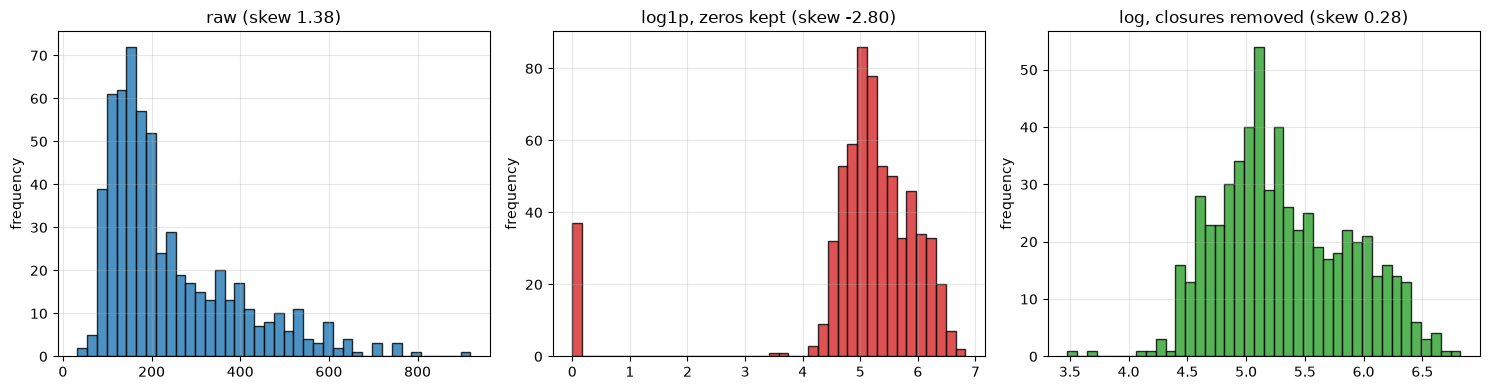

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(open_days.values, bins=40, edgecolor="black", alpha=0.8)
axes[0].set_title(f"raw (skew {open_days.skew():.2f})")

axes[1].hist(log_naive.dropna().values, bins=40, edgecolor="black", alpha=0.8, color="tab:red")
axes[1].set_title(f"log1p, zeros kept (skew {log_naive.skew():.2f})")

axes[2].hist(log_clean.values, bins=40, edgecolor="black", alpha=0.8, color="tab:green")
axes[2].set_title(f"log, closures removed (skew {log_clean.skew():.2f})")

for a in axes:
    a.set_ylabel("frequency")
plt.tight_layout()
plt.show()

In [13]:
# Retransformation bias, measured
z = log_clean
sigma2 = z.var()

naive_back     = np.exp(z.mean())
corrected_back = np.exp(z.mean() + 0.5 * sigma2)

print(f"true mean of y            : {open_days.mean():.1f}")
print(f"exp(mean of log y)        : {naive_back:.1f}   <- the median, biased low")
print(f"exp(mean + sigma^2 / 2)   : {corrected_back:.1f}")
print(f"true median of y          : {open_days.median():.1f}")
print(f"\nnaive back-transform under-predicts the mean by "
      f"{100*(1 - naive_back/open_days.mean()):.1f}%")

true mean of y            : 241.3
exp(mean of log y)        : 205.3   <- the median, biased low
exp(mean + sigma^2 / 2)   : 240.0
true median of y          : 190.4

naive back-transform under-predicts the mean by 14.9%


**Observations**

- **The naive transform is worse than none.** `log1p` with zeros kept swings skew from **+1.383** to **-2.800**; removing the 37 closure days first and taking logs gives **+0.279**, near symmetric. Order of operations decides the outcome.
- Variance stabilisation works: the rolling-std max/min ratio falls from **6.58** to **3.06**, and `corr(rolling mean, rolling std)` flips from **+0.709** (spread tracks level) to **-0.294** (mildly over-corrected).
- Retransformation bias is not academic here: `exp(mean(log y))` gives **205.3** against a true mean of **241.3** -- a **14.9% under-prediction**. Applying the $\sigma^2/2$ correction recovers **240.0**, within 0.5% of the truth.
- What the naive back-transform actually returns is the **geometric mean** (205.3). Under exact lognormality that would equal the median, but the empirical median here is **190.4** -- an ~8% gap, so the distribution is not quite lognormal.
- If your loss is MAE, a central estimate like this is roughly the right target and no correction is needed. For MSE/RMSE, or for anything summed into a revenue figure, apply the correction.

## 6. Box-Cox transformation

The log is one point in a family. Box-Cox estimates the exponent from the data:

$$y^{(\lambda)}_t = \begin{cases} \dfrac{y_t^{\lambda} - 1}{\lambda}, & \lambda \neq 0 \\[2ex] \log(y_t), & \lambda = 0 \end{cases}$$

$\lambda$ is chosen by maximum likelihood to make the result as close to Gaussian as possible. Common values:

| $\lambda$ | Equivalent to |
|---|---|
| 1 | no transform (just shifted) |
| 0.5 | square root -- mild, good for counts |
| 0 | log |
| -0.5 | reciprocal square root |
| -1 | reciprocal |

**Requirements and cautions**

- $y > 0$ strictly. Zeros need Yeo-Johnson instead, which extends the family to non-positive values.
- **$\lambda$ must be estimated on the training split only**, then reused on test. Re-estimating on the full series is leakage.
- $\lambda$ is fitted for **normality**, which is not the same objective as variance stability -- as this series demonstrates.
- Inverse: $y = (\lambda y^{(\lambda)} + 1)^{1/\lambda}$ for $\lambda \neq 0$. Same retransformation bias as the log.

In [14]:
bc_values, lam = stats.boxcox(open_days.values)
bc = pd.Series(bc_values, index=open_days.index)

print(f"estimated lambda = {lam:.4f}")
print(f"  -> between log (0) and reciprocal root (-0.5); log is a defensible simplification\n")

rows = []
for name, series in [("raw", open_days), ("log", log_clean), (f"box-cox (λ={lam:.2f})", bc)]:
    m, sd = series.rolling(30).mean(), series.rolling(30).std()
    rows.append({
        "transform": name,
        "skew": round(series.skew(), 3),
        "kurtosis": round(series.kurt(), 3),
        "roll-std ratio": round(sd.max() / sd.min(), 2),
        "corr(mean,std)": round(m.corr(sd), 3),
    })
pd.DataFrame(rows)

estimated lambda = -0.2034
  -> between log (0) and reciprocal root (-0.5); log is a defensible simplification



,transform,skew,kurtosis,roll-std ratio,"corr(mean,std)"
0,raw,1.383,1.632,6.58,0.709
1,log,0.279,-0.459,3.06,-0.294
2,box-cox (λ=-0.20),0.014,-0.258,3.95,-0.532


In [15]:
# Fit lambda on TRAIN only, then apply to test — the leakage-safe pattern
split = int(len(open_days) * 0.8)
train, test = open_days.iloc[:split], open_days.iloc[split:]

_, lam_train = stats.boxcox(train.values)
print(f"lambda fitted on train only : {lam_train:.4f}")
print(f"lambda fitted on everything : {lam:.4f}")

test_bc = stats.boxcox(test.values, lmbda=lam_train)          # apply, do not refit
back    = inv_boxcox(test_bc, lam_train)                      # invert

print(f"\nround-trip max abs error: {np.abs(back - test.values).max():.2e}")

lambda fitted on train only : -0.1956
lambda fitted on everything : -0.2034

round-trip max abs error: 1.08e-12


**Observations**

- **$\lambda = -0.2034$** -- close enough to 0 that the log is a reasonable simplification, and easier to explain and invert.
- Box-Cox wins on **normality**: skew **0.014** (vs 0.279 for log) and kurtosis **-0.258**. Essentially symmetric.
- But log wins on **variance stability**: rolling-std ratio **3.06** vs **3.95**, and `corr(mean, std)` of **-0.294** vs **-0.532** -- Box-Cox over-corrects, so the spread now shrinks as the level grows. This is the objective mismatch: MLE targets Gaussianity, not homoscedasticity.
- The train-only $\lambda$ (**-0.1956**) differs from the full-sample one (**-0.2034**); on the section-10 split it moves further, to **-0.1316**. Small differences here, but the discipline is what matters -- and the round-trip inverse is exact to ~1e-12.
- **Verdict for this series:** use the log. It is nearly as good on every criterion, better on variance, trivially invertible, and interpretable as percentage change.

## 7. Differencing

Differencing removes trend and is the standard route to stationarity -- the $d$ in ARIMA$(p,d,q)$.

**First difference** (removes a linear trend, converts a random walk to white noise):

$$\Delta y_t = y_t - y_{t-1}$$

**Second difference** (removes a quadratic trend) -- rarely needed beyond $d = 2$:

$$\Delta^2 y_t = \Delta(\Delta y_t) = y_t - 2y_{t-1} + y_{t-2}$$

In backshift notation $\Delta = (1 - B)$, so $\Delta^d y_t = (1-B)^d y_t$.

**Costs:** each difference destroys one row, amplifies noise, and changes what you are modelling (the *change*, not the level). Forecasts must be integrated back with a cumulative sum, anchored on the last observed value.

**How many differences?** Use a unit-root test, not intuition. The **ADF test** has $H_0$: a unit root is present (non-stationary); $p < 0.05$ rejects it. Difference the minimum number of times that achieves stationarity -- **over-differencing** inflates variance and induces a spurious negative MA(1) term.

In [16]:
def adf_report(series, label):
    series = series.dropna()
    stat, p, lags, nobs, crit, _ = adfuller(series, autolag="AIC")
    return {
        "series": label,
        "ADF stat": round(stat, 3),
        "p-value": f"{p:.3g}",
        "stationary at 5%": "yes" if p < 0.05 else "no",
        "std": round(series.std(), 2),
    }

report = pd.DataFrame([
    adf_report(y,                    "y (raw)"),
    adf_report(np.log(open_days),    "log(y), closures out"),
    adf_report(y.diff(),             "Δy  (d=1)"),
    adf_report(y.diff().diff(),      "Δ²y (d=2)"),
])
report

,series,ADF stat,p-value,stationary at 5%,std
0,y (raw),-2.886,0.047,yes,153.84
1,"log(y), closures out",-3.111,0.0258,yes,0.56
2,Δy (d=1),-5.730,6.62e-07,yes,102.73
3,Δ²y (d=2),-10.430,1.62e-18,yes,156.59


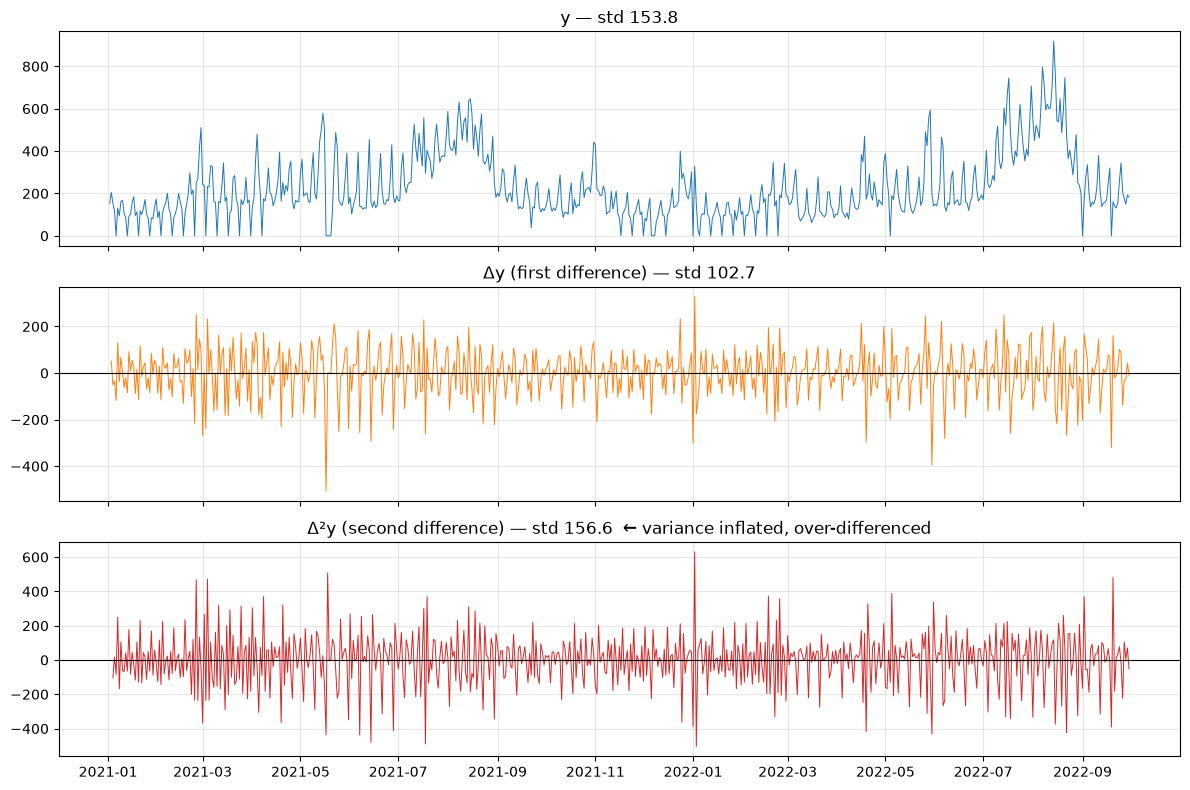

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(y.index, y.values, lw=0.7)
axes[0].set_title(f"y — std {y.std():.1f}")

d1 = y.diff()
axes[1].plot(d1.index, d1.values, lw=0.7, color="tab:orange")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title(f"Δy (first difference) — std {d1.std():.1f}")

d2 = y.diff().diff()
axes[2].plot(d2.index, d2.values, lw=0.7, color="tab:red")
axes[2].axhline(0, color="black", lw=0.8)
axes[2].set_title(f"Δ²y (second difference) — std {d2.std():.1f}  ← variance inflated, over-differenced")

plt.tight_layout()
plt.show()

**Observations**

- The raw series sits right on the boundary: ADF **-2.886, p = 0.047**. Technically stationary at 5%, but only because the ADF test is being confused by the strong seasonality -- the rolling-mean plot in the EDA says otherwise. **Never read a unit-root test in isolation on a seasonal series.**
- One difference is decisive: **-5.730, p = 6.6e-07**, with std dropping from **153.8** to **102.7**.
- The second difference is a textbook **over-differencing** demonstration: std jumps back up to **156.6**, well above the first difference's 102.7. The variance increase is the diagnostic -- stop at $d = 1$.
- Even after differencing, the weekly spikes remain visible. First differencing removes *trend*, not *seasonality*. That is the next section.

## 8. Seasonal differencing

To remove a season of period $m$, subtract the value from one full season ago:

$$\Delta_m y_t = y_t - y_{t-m} \qquad (m = 7 \text{ here})$$

In backshift notation $\Delta_m = (1 - B^m)$, giving the $D$ in SARIMA$(p,d,q)(P,D,Q)_m$.

This is "how does this Monday compare with last Monday" -- it strips out the weekly pattern **and** any constant level, which is why a seasonal difference alone often achieves stationarity.

**Combined with a first difference:**

$$\Delta \Delta_m y_t = (1-B)(1-B^m) y_t = y_t - y_{t-1} - y_{t-m} + y_{t-m-1}$$

**Order of operations:** apply the **seasonal difference first**, then test whether a first difference is still needed. Seasonal differencing frequently removes the trend as a side effect, and the reverse order tends to over-difference. Each seasonal difference costs $m$ rows -- 7 here, but 12 for monthly data and 52 for weekly.

In [18]:
variants = {
    "y (raw)":            y,
    "Δ₇y  (D=1)":         y.diff(SEASON),
    "Δy   (d=1)":         y.diff(),
    "ΔΔ₇y (d=1, D=1)":    y.diff(SEASON).diff(),
    "Δ₇Δ₇y (D=2)":        y.diff(SEASON).diff(SEASON),
}

pd.DataFrame([adf_report(v, k) for k, v in variants.items()])

,series,ADF stat,p-value,stationary at 5%,std
0,y (raw),-2.886,0.047,yes,153.84
1,Δ₇y (D=1),-6.109,9.44e-08,yes,101.75
2,Δy (d=1),-5.730,6.62e-07,yes,102.73
3,"ΔΔ₇y (d=1, D=1)",-8.736,3.09e-14,yes,86.89
4,Δ₇Δ₇y (D=2),-9.097,3.68e-15,yes,158.94


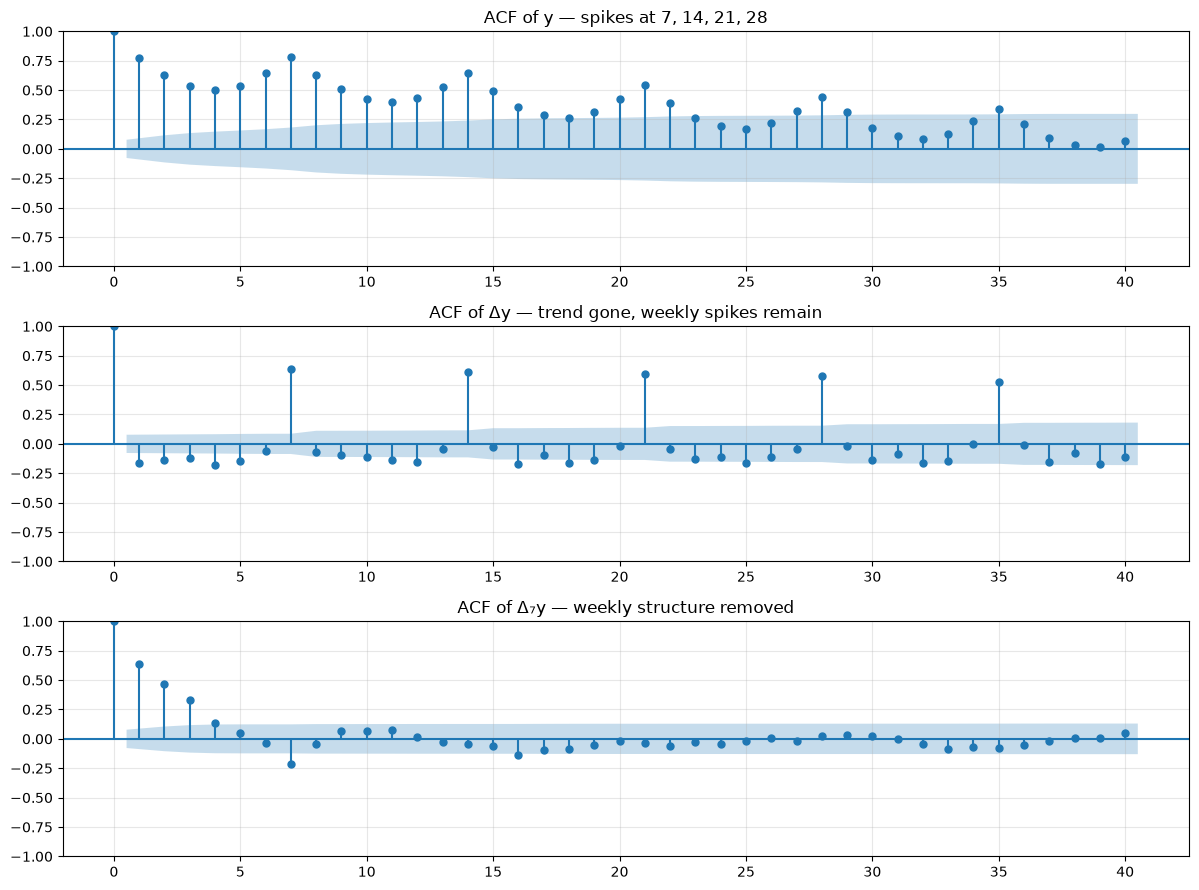

In [19]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(3, 1, figsize=(12, 9))

plot_acf(y.dropna(), lags=40, ax=axes[0])
axes[0].set_title("ACF of y — spikes at 7, 14, 21, 28")

plot_acf(y.diff().dropna(), lags=40, ax=axes[1])
axes[1].set_title("ACF of Δy — trend gone, weekly spikes remain")

plot_acf(y.diff(SEASON).dropna(), lags=40, ax=axes[2])
axes[2].set_title("ACF of Δ₇y — weekly structure removed")

plt.tight_layout()
plt.show()

**Observations**

- A **seasonal difference alone** takes the series to ADF **-6.109 (p = 9.4e-08)** and cuts std from 153.8 to **101.8** -- slightly better than a first difference (102.7) and it removes the weekly pattern too. If you may only take one difference on this series, take the seasonal one.
- **$\Delta\Delta_7$ is the strongest by both criteria**: ADF **-8.736 (p = 3.1e-14)** and std **86.9**, the lowest of any variant. Because variance *falls* rather than rises, this is not over-differencing -- both components were genuinely present. That is $d = 1, D = 1$, i.e. `SARIMA(p,1,q)(P,1,Q)[7]`.
- A **second seasonal difference is over-differencing**: std climbs back to **158.9**. The variance rule catches it immediately.
- The ACF panels tell the story visually: the raw ACF has spikes at every multiple of 7; after $\Delta$ the decay is gone but the weekly spikes survive; after $\Delta_7$ the weekly structure is gone. Two different problems needing two different tools.

## 9. Handling missing values and outliers

### 9a. Missing values

The first job is to distinguish three cases that look identical in a dataframe:

| Case | Example here | Correct handling |
|---|---|---|
| **Missing row** | date absent from the file | reindex to a full calendar -> becomes an explicit `NaN` |
| **Structural zero** | 37 closure days | keep as a **flag**, exclude from demand modelling |
| **Genuine zero** | open but sold nothing | keep as data |

`asfreq("D")` is what surfaces case 1: without it, gaps are invisible and every rolling window silently spans them.

Imputation options, weakest to strongest:

- `ffill` / `bfill` -- carry the neighbour. Fast, but flat and ignores seasonality.
- `interpolate("linear" / "time")` -- straight line between neighbours. `"time"` respects unequal spacing.
- **Seasonal-aware** -- deseasonalise, interpolate the smooth remainder, then re-apply the seasonal factor. More work, materially better.

Also: for real-time simulation only `ffill` is legitimate -- interpolation uses the *next* value, which is future information. On historical training data that is usually fine, but never impute a **validation target** this way.

In [20]:
# Closures are structural, not missing: mark them explicitly
is_closed = (y == 0)
open_only = y.where(~is_closed)          # closures -> NaN

print(f"closure days flagged : {int(is_closed.sum())}")
print(f"open days            : {int(open_only.notna().sum())}")

# Benchmark: punch holes in known values, then measure how well each method recovers them
rng   = np.random.default_rng(42)
known = open_only.dropna().index
holes = rng.choice(known, size=int(0.05 * len(known)), replace=False)

holed = open_only.copy()
truth = open_only.loc[holes].copy()
holed.loc[holes] = np.nan

def score(filled):
    return np.abs(filled.loc[holes] - truth).mean()

# seasonal-aware: multiplicative weekday factors from the ratio to a local 7-day mean
local   = holed.rolling(7, center=True, min_periods=4).mean()
factors = (holed / local).groupby(holed.index.dayofweek).mean()
deseas  = holed / holed.index.dayofweek.map(factors)
seasonal_filled = deseas.interpolate("time") * holed.index.dayofweek.map(factors)

methods = {
    "ffill":                 holed.ffill(),
    "bfill":                 holed.bfill(),
    "interpolate(linear)":   holed.interpolate("linear"),
    "interpolate(time)":     holed.interpolate("time"),
    "seasonal naive lag-7":  holed.fillna(holed.shift(SEASON)),
    "deseasonalised + time": seasonal_filled,
}

print(f"\nrecovering {len(holes)} artificial holes (MAE, lower is better)")
for name, filled in sorted(methods.items(), key=lambda kv: score(kv[1])):
    print(f"  {name:24s} {score(filled):7.2f}")

print("\nmultiplicative weekday factors:")
print({d: round(f, 2) for d, f in factors.items()})

closure days flagged : 37
open days            : 600

recovering 30 artificial holes (MAE, lower is better)
  deseasonalised + time      23.49
  interpolate(linear)        38.03
  interpolate(time)          38.03
  bfill                      52.90
  ffill                      57.74
  seasonal naive lag-7       75.62

multiplicative weekday factors:
{0: 0.94, 1: 0.79, 2: 0.76, 3: 0.82, 4: 0.83, 5: 1.19, 6: 1.55}


**Observations**

- **Deseasonalise before interpolating: MAE 23.49 vs 38.03 for plain interpolation** -- a 38% improvement for a few lines of code. Interpolating across a Sunday from its Saturday and Monday neighbours ignores that Sunday runs ~1.55x the local average.
- Plain `linear` and `time` interpolation are identical (**38.03**) because the index is evenly spaced -- `time` only differs on irregular indices.
- `ffill` (**57.74**) and `bfill` (**52.90**) are markedly worse: carrying yesterday forward means carrying yesterday's *weekday effect* forward.
- **`seasonal naive lag-7` is the worst of all (75.62)** despite being seasonally correct. It uses one noisy observation from seven days ago, and on a series with a steep annual trend that value is also from a different level. Correct seasonality, wrong level -- you need both.
- The weekday factors are informative in their own right: **Sunday 1.55, Saturday 1.19, Monday 0.94, Friday 0.83, Thursday 0.82, Tuesday 0.79, Wednesday 0.76.**

### 9b. Outliers

In a time series an outlier is defined **relative to what was expected at that timestamp**, not relative to the global distribution. Peak-summer Sundays are extreme globally but entirely normal seasonally -- a global rule would delete the most informative points in the series.

| Method | Rule | Weakness |
|---|---|---|
| **IQR** | outside $Q_1 - 1.5\,\text{IQR}$, $Q_3 + 1.5\,\text{IQR}$ | ignores time; flags the whole peak season |
| **z-score** | $\lvert z \rvert > 3$ | mean and std are themselves inflated by the outliers |
| **Rolling median + MAD** | $\lvert 0.6745\,(y_t - \tilde{y}_t) / \text{MAD}_t \rvert > 3.5$ | robust and local, but blind to seasonality within the window |
| **STL residual** | decompose, then apply MAD to the remainder | best -- removes trend *and* season before judging |

The MAD-based modified z-score uses

$$M_t = \frac{0.6745\,(y_t - \tilde{y}_t)}{\text{MAD}_t}, \qquad \text{MAD} = \text{median}\lvert y_i - \tilde{y} \rvert$$

where 0.6745 rescales MAD to be comparable with a standard deviation under normality.

**Then what?** Rarely delete. Prefer: **cap** (winsorise) at the threshold, **replace** by the seasonal expectation, or -- usually best -- **keep the value and add a binary flag** so the model can learn the effect instead of being told to ignore it.

In [21]:
s_open = open_only.dropna()

# 1. global IQR
q1, q3 = s_open.quantile([0.25, 0.75])
iqr = q3 - q1
iqr_flag = (s_open < q1 - 1.5 * iqr) | (s_open > q3 + 1.5 * iqr)

# 2. global z-score
z_flag = ((s_open - s_open.mean()) / s_open.std()).abs() > 3

# 3. rolling median + MAD (local, robust)
med = s_open.rolling(29, center=True, min_periods=5).median()
mad = (s_open - med).abs().rolling(29, center=True, min_periods=5).median()
mad_flag = (0.6745 * (s_open - med) / mad.replace(0, np.nan)).abs() > 3.5

# 4. STL residual + MAD (removes trend and season first)
stl   = STL(s_open.asfreq("D").interpolate(), period=SEASON, robust=True).fit()
resid = stl.resid
stl_flag = (0.6745 * (resid - resid.median()) / (resid - resid.median()).abs().median()).abs() > 3.5

for name, flag in [("IQR (global)", iqr_flag), ("z-score > 3 (global)", z_flag),
                   ("rolling median + MAD", mad_flag), ("STL residual + MAD", stl_flag)]:
    n = int(flag.sum())
    print(f"  {name:24s} {n:3d} flagged ({100*n/len(s_open):4.1f}%)")

print("\nmonth distribution of IQR-flagged points (global rule):")
print(s_open[iqr_flag].groupby(s_open[iqr_flag].index.month).size().to_dict())

  IQR (global)              22 flagged ( 3.7%)
  z-score > 3 (global)       8 flagged ( 1.3%)
  rolling median + MAD      22 flagged ( 3.7%)
  STL residual + MAD        65 flagged (10.8%)

month distribution of IQR-flagged points (global rule):
{5: 1, 7: 5, 8: 16}


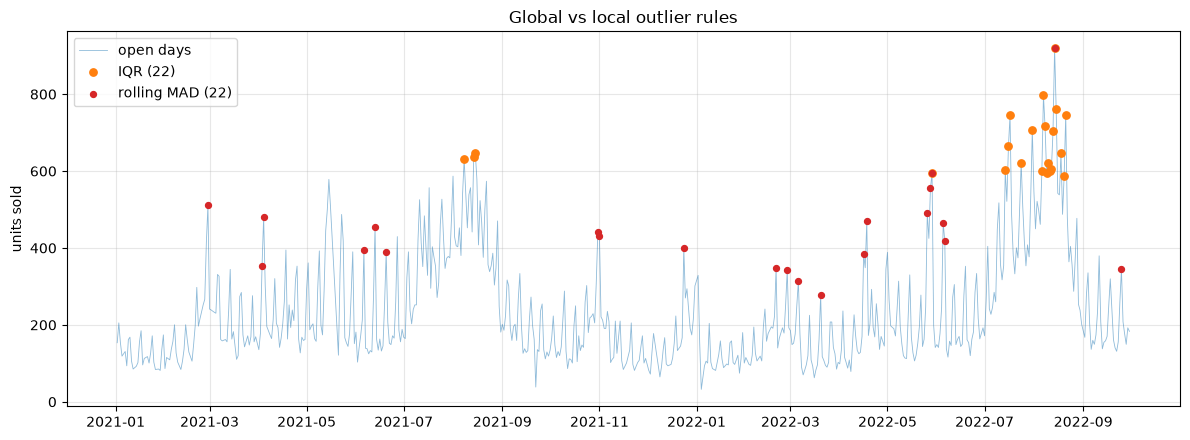

In [22]:
fig, ax = plt.subplots(figsize=(12, 4.5))

ax.plot(s_open.index, s_open.values, lw=0.6, alpha=0.5, label="open days")
ax.scatter(s_open[iqr_flag].index, s_open[iqr_flag], s=28, color="tab:orange",
           label=f"IQR ({int(iqr_flag.sum())})", zorder=3)
ax.scatter(s_open[mad_flag.fillna(False)].index, s_open[mad_flag.fillna(False)], s=18,
           color="tab:red", label=f"rolling MAD ({int(mad_flag.sum())})", zorder=4)
ax.set_title("Global vs local outlier rules")
ax.set_ylabel("units sold")
ax.legend()

plt.tight_layout()
plt.show()

In [23]:
# Preferred treatment: keep the value, add a flag, and cap only the extremes
features_out = pd.DataFrame({
    "y": y,
    "is_closed":  is_closed.astype(int),
    "is_outlier": mad_flag.reindex(y.index).fillna(False).astype(int),
})

lo, hi = s_open.quantile([0.01, 0.99])
features_out["y_winsorised"] = y.clip(lower=lo, upper=hi).where(~is_closed)

print(f"winsorising bounds (1st/99th pct): {lo:.1f} — {hi:.1f}")
print(f"values capped: {int(((y < lo) | (y > hi)).sum() - is_closed.sum())}")
features_out.loc[features_out['is_outlier'] == 1].head()

winsorising bounds (1st/99th pct): 74.4 — 707.3
values capped: 12


,y,is_closed,is_outlier,y_winsorised
ds,,,,
2021-02-28,511.2,0,1,511.2
2021-04-03,352.8,0,1,352.8
2021-04-04,480.0,0,1,480.0
2021-06-06,394.8,0,1,394.8
2021-06-13,454.8,0,1,454.8


**Observations**

- The four rules disagree wildly: **8** points (z-score), **22** (IQR and rolling MAD), **65** (STL residual). None is "correct" -- each answers a different question, so the threshold is a modelling decision, not a data fact.
- **The global IQR rule is actively harmful here.** Twenty-one of its 22 flagged points fall in **July (5) and August (16)**, the remaining one in May -- it is not finding anomalies, it is finding *summer*. Dropping them would delete the peak season the business most needs forecast.
- The rolling MAD rule flags the same count but spreads them across the year, catching genuine local surprises rather than seasonal highs.
- STL + MAD flags 10.8% of points, which is far too many to be "outliers" -- the residual MAD is small, so the threshold needs raising. Worth tuning rather than accepting the default.
- The closure days are handled separately as a **flag**, not as outliers. Structural zeros and anomalies are different phenomena and mixing them corrupts both.

## 10. Putting it together: a leakage-safe pipeline

The syllabus order above is not the execution order. In a real pipeline:

```
1. Fix the calendar          asfreq — make gaps explicit
2. Separate structural zeros closures -> flag, not demand
3. Handle missing/outliers   deseasonalised interpolation; flag, don't delete
4. Split train / test        BEFORE fitting anything
5. Transform                 log or Box-Cox, lambda fitted on TRAIN only
6. Difference                if the model needs stationarity (ARIMA does; trees don't)
7. Build features            lags, rolling, expanding, calendar — all shifted by >= h
8. Drop warm-up rows         the NaNs the lags and windows create
```

Steps 4 and 5 are the ones people get wrong. Anything **estimated from data** -- $\lambda$, imputation values, outlier thresholds, scaler statistics -- is a parameter, and parameters are fitted on training data only.

Note that steps 5 and 6 are model-dependent: gradient-boosted trees need neither a transform nor differencing, and giving them differenced targets often hurts. ARIMA needs both.

In [24]:
def build_features(series, horizon=7, season=7, lags=(7, 14, 21, 28), windows=(7, 28)):
    '''Assemble a leakage-safe feature matrix. Every feature uses data <= t - horizon.'''
    df = pd.DataFrame({"y": series})

    # structural zeros as a flag, not as demand
    df["is_closed"] = (series == 0).astype(int)

    # lags — all >= horizon so they are known at prediction time
    for k in lags:
        assert k >= horizon, f"lag {k} is not available {horizon} steps ahead"
        df[f"lag_{k}"] = series.shift(k)

    # rolling statistics, shifted by the horizon
    base = series.shift(horizon)
    for w in windows:
        df[f"roll{w}_mean"] = base.rolling(w).mean()
        df[f"roll{w}_std"]  = base.rolling(w).std()
        df[f"roll{w}_min"]  = base.rolling(w).min()
        df[f"roll{w}_max"]  = base.rolling(w).max()

    # expanding — cumulative, also shifted
    df["expanding_mean"] = base.expanding(min_periods=season).mean()

    # calendar — free, no rows lost, known for any future date
    df = df.join(calendar_features(series.index))

    return df

feat = build_features(y, horizon=HORIZON, season=SEASON)

print("feature matrix :", feat.shape)
print("warm-up rows lost:", int(feat.isna().any(axis=1).sum()))
feat_clean = feat.dropna()
print("usable rows      :", len(feat_clean))
feat_clean.head()

feature matrix : (637, 32)
warm-up rows lost: 34
usable rows      : 603


,y,is_closed,lag_7,lag_14,lag_21,lag_28,roll7_mean,roll7_std,roll7_min,roll7_max,roll28_mean,roll28_std,roll28_min,roll28_max,expanding_mean,...,month,quarter,weekofyear,dayofyear,is_weekend,is_month_start,is_month_end,dow_sin,dow_cos,year_sin1,year_cos1,year_sin2,year_cos2,year_sin3,year_cos3
ds,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2021-02-05,136.8,0,81.6,100.8,102.0,93.6,93.257143,52.236605,0.0,171.6,106.842857,55.488600,0.0,205.2,106.842857,...,2,1,5,36,0,0,0,-0.433884,-0.900969,0.580455,0.814292,0.945320,0.326144,0.959079,-0.283139
2021-02-06,157.2,0,135.6,127.2,156.0,162.0,94.457143,53.233287,0.0,171.6,106.200000,55.029204,0.0,205.2,107.834483,...,2,1,5,37,1,0,0,-0.974928,-0.222521,0.594376,0.804187,0.955979,0.293434,0.943196,-0.332235
2021-02-07,200.4,0,174.0,171.6,184.8,168.0,94.800000,53.817469,0.0,174.0,105.085714,53.237008,0.0,184.8,110.040000,...,2,1,5,38,1,0,0,-0.781831,0.623490,0.608121,0.793844,0.965507,0.260376,0.924803,-0.380447
2021-02-08,127.2,0,86.4,103.2,96.0,105.6,92.400000,53.755000,0.0,174.0,102.685714,52.478240,0.0,184.8,109.277419,...,2,1,6,39,0,0,0,0.000000,1.000000,0.621687,0.783266,0.973892,0.227011,0.903946,-0.427646
2021-02-09,103.2,0,115.2,84.0,112.8,85.2,96.857143,54.233780,0.0,174.0,102.557143,52.441696,0.0,184.8,109.462500,...,2,1,6,40,0,0,0,0.781831,0.623490,0.635068,0.772456,0.981125,0.193376,0.880683,-0.473706


In [25]:
# Split first, then fit the transform on train only
split_at = feat_clean.index[-56]                       # last 8 weeks held out
train_f  = feat_clean[feat_clean.index <  split_at]
test_f   = feat_clean[feat_clean.index >= split_at]

train_open = train_f.loc[train_f["is_closed"] == 0, "y"]
_, lam_tr  = stats.boxcox(train_open.values)

print(f"train rows: {len(train_f)}   test rows: {len(test_f)}")
print(f"lambda fitted on train only: {lam_tr:.4f}")
print(f"(fitting on everything would have given {lam:.4f} — the difference is the leak)")

print("\nfeature groups:")
groups = {
    "target/flags": [c for c in feat_clean.columns if c in ("y", "is_closed")],
    "lags":         [c for c in feat_clean.columns if c.startswith("lag_")],
    "rolling":      [c for c in feat_clean.columns if c.startswith("roll")],
    "expanding":    [c for c in feat_clean.columns if c.startswith("expanding")],
    "calendar":     [c for c in feat_clean.columns if c in calendar_features(y.index).columns],
}
for g, cols in groups.items():
    print(f"  {g:14s} {len(cols):2d}  {cols[:4]}{' ...' if len(cols) > 4 else ''}")

train rows: 547   test rows: 56
lambda fitted on train only: -0.1316
(fitting on everything would have given -0.2034 — the difference is the leak)

feature groups:
  target/flags    2  ['y', 'is_closed']
  lags            4  ['lag_7', 'lag_14', 'lag_21', 'lag_28']
  rolling         8  ['roll7_mean', 'roll7_std', 'roll7_min', 'roll7_max'] ...
  expanding       1  ['expanding_mean']
  calendar       17  ['dayofweek', 'day', 'month', 'quarter'] ...


## Summary

| Technique | Formula | Result on this series |
|---|---|---|
| Lag features | $y_{t-k}$ | lag 364 strongest ($r = 0.816$), then lag 7 (0.783), lag 1 (0.777) |
| Rolling stats | $\frac{1}{w}\sum_{i=t-w}^{t-1} y_i$ | unshifted `roll7_mean` correlates 0.801 vs 0.763 shifted — the leak |
| Expanding | $\frac{1}{t-1}\sum_{i<t} y_i$ | near-constant (~227); useful for YTD totals and CV design, not as a level |
| Calendar | `dayofweek`, `month`, ... | `is_weekend` alone correlates +0.379, and costs zero rows |
| Cyclical encoding | $\sin/\cos(2\pi t/m)$ | Sun->Mon distance 6 (ordinal) becomes 0.868, equal to every other step |
| Log | $\log y_t$ | skew 1.383 -> 0.279; rolling-std ratio 6.58 -> 3.06 |
| Box-Cox | $(y^\lambda - 1)/\lambda$ | $\lambda = -0.203$; best skew (0.014) but worse variance stability than log |
| Differencing | $y_t - y_{t-1}$ | ADF -2.886 -> -5.730; $d=2$ inflates std to 156.6 (over-differenced) |
| Seasonal differencing | $y_t - y_{t-7}$ | ADF -6.109; combined $\Delta\Delta_7$ best at -8.736, std 86.9 |
| Missing values | — | deseasonalised interpolation MAE 23.49 vs 38.03 plain, 75.62 seasonal-naive |
| Outliers | $0.6745(y-\tilde{y})/\text{MAD}$ | global IQR flags only Jul/Aug — it finds *summer*, not anomalies |

### The five things worth remembering

1. **Shift before you roll.** `y.rolling(w)` includes $y_t$. For an $h$-step horizon, shift by $h$ -- and every lag must satisfy $k \geq h$.
2. **Fit transform parameters on train only.** $\lambda$, imputation values, thresholds and scalers are all fitted quantities.
3. **Order of operations changes the answer.** `log1p` before removing closures makes skew *worse* than doing nothing (+1.383 -> -2.801); removing them first gives +0.279.
4. **Seasonality belongs in your imputation and your outlier rule**, not just in your model. Both improved by 30-40% once the weekly pattern was accounted for.
5. **Watch variance when differencing.** Falling variance means the difference was needed; rising variance means you over-differenced.

**Next:** Module 3 — stationarity and diagnostics (unit roots, ACF/PACF interpretation, white noise and random walks).